In [7]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBRegressor
from sklearn.svm import NuSVR
from sklearn.model_selection import cross_val_score
from sklearn.metrics import make_scorer
import pandas as pd
import numpy as np
import function as f 

# Load data
train_data, test_data = f.read_file('train.csv','test.csv')

# Drop categorical values
test_data = test_data.drop(['SMILES', 'mol','Compound'], axis=1)
train_data = train_data.drop(['SMILES','mol','Compound'], axis=1)

# Columns to encode
columns_to_encode = ['Lab']

# OneHotEncoder on train_data and test_data
train_data ,test_data = f.apply_one_hot_encoding(train_data, test_data, columns_to_encode)

# Clean both train and test data using these columns
# train_data, test_data = f.clean_data(train_data, test_data)

def identify_columns_to_drop(df):
    """
    Identify columns to drop based on NaN values, constant predictors, and perfectly correlated predictors.

    Parameters:
    - df: DataFrame containing the data.

    Returns:
    - columns_to_drop: Array of column names to be dropped.
    """
    # Drop nan values
    if df.isna().any().any():
        df = df.dropna(inplace = True)

    # Identifies constant predictors
    thr = 0.05
    constant_columns = df.columns[df.std(axis=0, numeric_only=True) <= thr]
    print(constant_columns.values)
    print(np.min(df.std()))
    # Identifies perfectly correlated predictors
    correlation = np.array(df.corr().values)
    correlation = np.triu(correlation, k=1)
    correlated_columns = df.columns[np.where(correlation == 1)[0]]

    # Combine constant and correlated columns
    columns_to_drop = np.union1d(constant_columns, correlated_columns)
    return columns_to_drop

# columns_to_drop = identify_columns_to_drop(train_data)
# print(columns_to_drop)
columns_to_drop = np.union1d(identify_columns_to_drop(train_data),identify_columns_to_drop(test_data))
print(columns_to_drop)
train_data = train_data.drop(columns=columns_to_drop, axis=1)
test_data = test_data.drop(columns=columns_to_drop, axis=1)


# Separate train and test data
X, y = train_data.drop('RT', axis=1), train_data['RT']

print(len(X.columns))

['ECFP_23' 'ECFP_109' 'ECFP_126' 'ECFP_184' 'ECFP_199' 'ECFP_225'
 'ECFP_321' 'ECFP_331' 'ECFP_341' 'ECFP_436' 'ECFP_482' 'ECFP_502'
 'ECFP_658' 'ECFP_749' 'ECFP_811' 'ECFP_841' 'ECFP_935']
0.03379167458201719
['ECFP_23' 'ECFP_56' 'ECFP_109' 'ECFP_126' 'ECFP_162' 'ECFP_170'
 'ECFP_184' 'ECFP_199' 'ECFP_332' 'ECFP_341' 'ECFP_366' 'ECFP_403'
 'ECFP_482' 'ECFP_538' 'ECFP_545' 'ECFP_656' 'ECFP_658' 'ECFP_661'
 'ECFP_663' 'ECFP_690' 'ECFP_749' 'ECFP_778' 'ECFP_784' 'ECFP_798'
 'ECFP_811' 'ECFP_813' 'ECFP_906' 'ECFP_935' 'ECFP_966' 'ECFP_1002'
 'ECFP_1017']
0.0
['ECFP_1002' 'ECFP_1017' 'ECFP_109' 'ECFP_126' 'ECFP_162' 'ECFP_170'
 'ECFP_184' 'ECFP_199' 'ECFP_225' 'ECFP_23' 'ECFP_321' 'ECFP_331'
 'ECFP_332' 'ECFP_341' 'ECFP_366' 'ECFP_403' 'ECFP_436' 'ECFP_482'
 'ECFP_502' 'ECFP_538' 'ECFP_545' 'ECFP_56' 'ECFP_656' 'ECFP_658'
 'ECFP_661' 'ECFP_663' 'ECFP_690' 'ECFP_749' 'ECFP_778' 'ECFP_784'
 'ECFP_798' 'ECFP_811' 'ECFP_813' 'ECFP_841' 'ECFP_906' 'ECFP_935'
 'ECFP_966']
1010


In [12]:
# Calculate the first and third quartiles
train_data, test_data = f.read_file('train.csv','test.csv')

# Drop categorical values
test_data = test_data.drop(['SMILES', 'mol','Compound'], axis=1)
train_data = train_data.drop(['SMILES','mol','Compound'], axis=1)

# Columns to encode
columns_to_encode = ['Lab']

# OneHotEncoder on train_data and test_data
train_data ,test_data = f.apply_one_hot_encoding(train_data, test_data, columns_to_encode)

df = train_data

Q1 = df['RT'].quantile(0.25)
Q3 = df['RT'].quantile(0.75)

# Calculate the IQR (Interquartile Range)
IQR = Q3 - Q1

# Define a threshold for outlier detection (e.g., 1.5 times the IQR)
threshold = 2

# Identify outliers
outliers = (df['RT'] < Q1 - threshold * IQR) | (df['RT'] > Q3 + threshold * IQR)

# Display the rows with outliers
outliers_df = df[outliers]
print("Rows with outliers:")
print(outliers_df)

Rows with outliers:
          RT  ECFP_1  ECFP_2  ECFP_3  ECFP_4  ECFP_5  ECFP_6  ECFP_7  ECFP_8  \
36    21.360       0       0       0       0       0       0       0       0   
133   20.170       0       1       0       0       0       0       0       0   
280   21.310       0       0       0       0       0       0       0       0   
458   19.840       0       0       0       0       0       0       0       0   
498   21.230       0       1       0       0       0       0       0       0   
573   20.210       0       0       0       0       0       0       0       0   
632   19.790       0       0       0       0       0       0       0       0   
634   19.870       0       0       0       0       0       0       0       0   
650   20.120       0       0       0       0       0       0       0       0   
698   20.190       0       0       0       0       1       0       0       0   
759   19.440       0       0       1       1       1       0       0       0   
803   19.490       0

In [17]:
# Isolation Forest
from sklearn.ensemble import IsolationForest
iso_forest = IsolationForest(contamination=0.01)  # Adjust the contamination parameter
outliers_iso = iso_forest.fit_predict(df[['RT']])
outliers_df_iso = df[outliers_iso == -1]
print("Rows with outliers (Isolation Forest):")
print(outliers_df_iso)

/Users/melina/opt/anaconda3/lib/python3.8/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


Rows with outliers (Isolation Forest):
         RT  ECFP_1  ECFP_2  ECFP_3  ECFP_4  ECFP_5  ECFP_6  ECFP_7  ECFP_8  \
36    21.36       0       0       0       0       0       0       0       0   
133   20.17       0       1       0       0       0       0       0       0   
280   21.31       0       0       0       0       0       0       0       0   
458   19.84       0       0       0       0       0       0       0       0   
498   21.23       0       1       0       0       0       0       0       0   
573   20.21       0       0       0       0       0       0       0       0   
632   19.79       0       0       0       0       0       0       0       0   
634   19.87       0       0       0       0       0       0       0       0   
650   20.12       0       0       0       0       0       0       0       0   
698   20.19       0       0       0       0       1       0       0       0   
957   20.31       0       1       1       0       1       0       0       0   
968   19.86  

Isolation Forest:
Nonlinear Relationships: Isolation Forest is effective when your data has complex and nonlinear relationships.
High-Dimensional Data: Isolation Forest can handle high-dimensional data well, making it suitable for datasets with many features.
Contamination Estimation: It allows you to set the contamination parameter to control the expected proportion of outliers in the dataset.


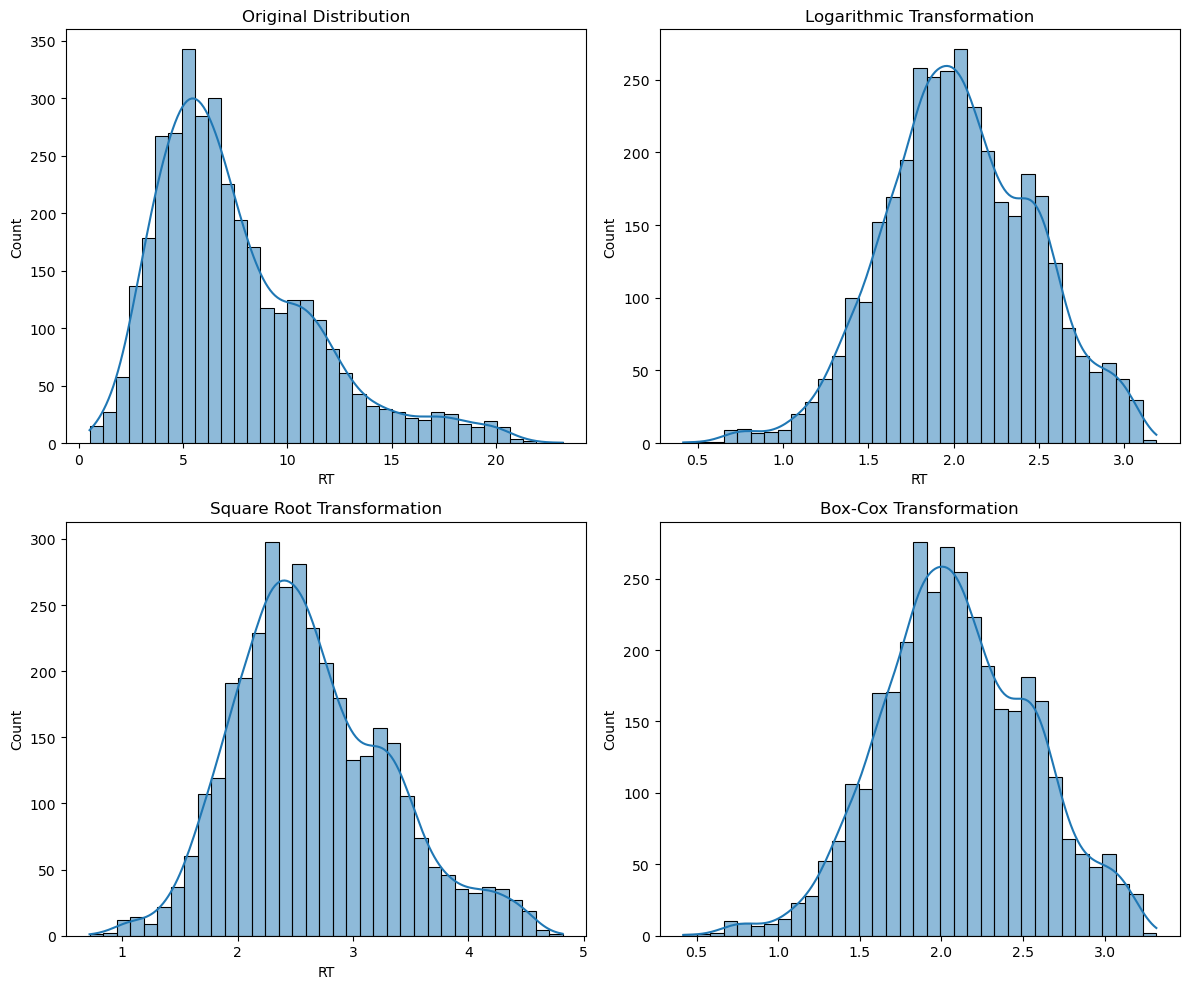

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import boxcox

# Assuming 'df' is your DataFrame and 'RT' is the column to transform
train_data, test_data = f.read_file('train.csv','test.csv')

# Drop categorical values
test_data = test_data.drop(['SMILES', 'mol', 'Compound'], axis=1)
train_data = train_data.drop(['SMILES', 'mol', 'Compound'], axis=1)

# Columns to encode
columns_to_encode = ['Lab']

# OneHotEncoder on train_data and test_data
train_data_encoded, test_data_encoded = f.apply_one_hot_encoding(train_data, test_data, columns_to_encode)

# Clean both train and test data using these columns
train_data, test_data = f.clean_data(train_data_encoded, test_data_encoded)
train_subset = int(len(train_data) * 0.8)

# Separate train and test data
X, y = train_data.drop('RT', axis=1), train_data['RT']
X_train, X_test, y_train, y_test = f.split_data(train_data)

# Create subplots
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))

# Original distribution
sns.histplot(y, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Original Distribution')

# Logarithmic Transformation
y_log = np.log1p(y)
sns.histplot(y_log, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Logarithmic Transformation')

# Square Root Transformation
y_sqrt = np.sqrt(y)
sns.histplot(y_sqrt, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Square Root Transformation')

# Box-Cox Transformation
y_boxcox, _ = boxcox(y + 1)  # Add 1 to handle zero values
sns.histplot(y_boxcox, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Box-Cox Transformation')

# Adjust layout
plt.tight_layout()
plt.show()


(3500, 1048)
(1375, 1030)
(3450, 1031)


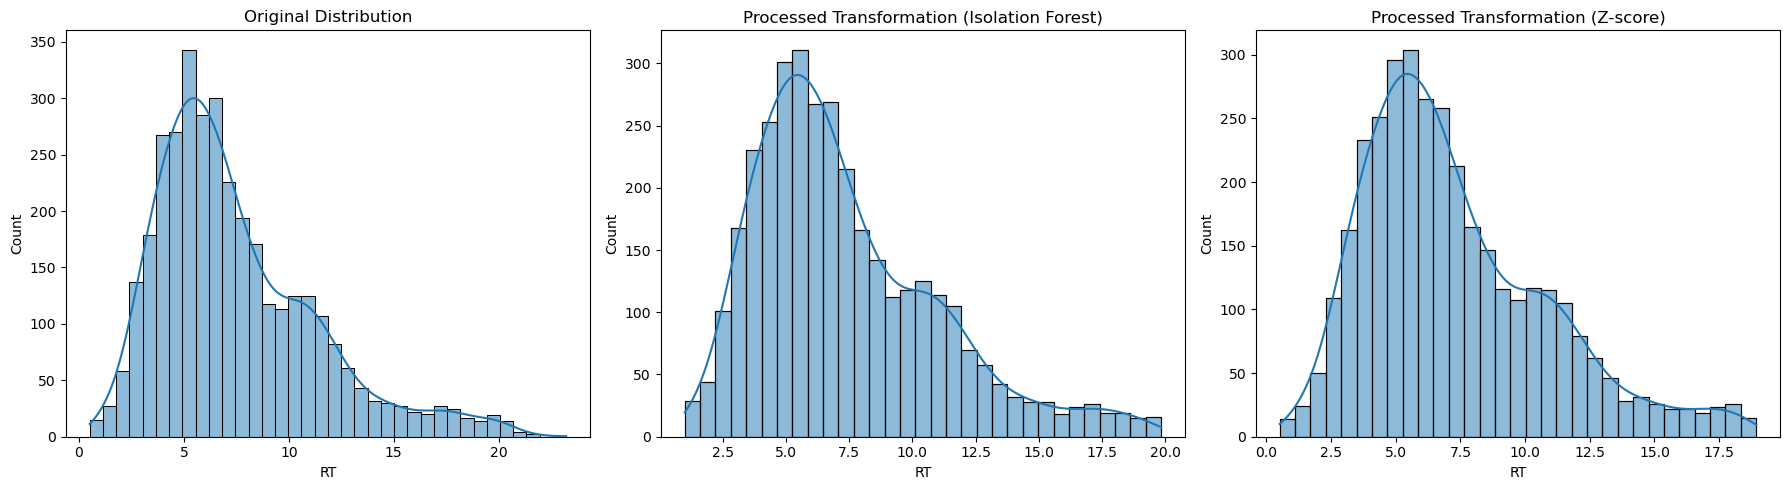

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import boxcox, zscore
import function as f
from sklearn.ensemble import IsolationForest

# Assuming 'df' is your DataFrame and 'RT' is the column to transform
train_data1, test_data1 = f.read_file('train.csv','test.csv')

test_data1 = test_data1.drop(['SMILES', 'mol','Compound'], axis=1)
train_data1 = train_data1.drop(['SMILES','mol','Compound'], axis=1)

# Columns to encode
columns_to_encode = ['Lab']

# OneHotEncoder on train_data and test_data
train_data1, test_data1 = f.apply_one_hot_encoding(train_data1, test_data1, columns_to_encode)


train_data2, test_data2 = f.read_file('train.csv','test.csv')


train_data2, test_data2 = f.process_data(train_data2, test_data2)
print(train_data1.shape)

iso_forest = IsolationForest(contamination=0.01, random_state=42)  # Adjust the contamination parameter
outliers = iso_forest.fit_predict(train_data2['RT'].values.reshape(-1, 1))
outlier_rows = train_data2['RT'].index[outliers == -1]
train_data_IF = train_data2.drop(index=outlier_rows)
print(test_data2.shape)



z_scores = zscore(train_data2['RT'])
outliers_z = (np.abs(z_scores) > 3)
train_data_Z = train_data2[~outliers_z]
print(train_data_Z.shape)

# # Create subplots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Original distribution
sns.histplot(train_data1['RT'], kde=True, ax=axes[0])
axes[0].set_title('Original Distribution')

# Processed Transformation with Isolation Forest
sns.histplot(train_data_IF['RT'], kde=True, ax=axes[1])
axes[1].set_title('Processed Transformation (Isolation Forest)')

# Processed Transformation with Z-score
sns.histplot(train_data_Z['RT'], kde=True, ax=axes[2])
axes[2].set_title('Processed Transformation (Z-score)')



# Adjust layout
plt.tight_layout()
plt.show()
